# Data Generation code

In [2]:
import pickle
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
from scipy.stats import pearsonr
import sys
import os

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})

In [18]:
# --- Parameters ---
track_length = 200.0  # cm
average_firing_rate = 5  # Hz
n_cells = 100  # Number of place cells
bins = np.arange(0., track_length)  # Spatial bins

# Place field parameters
pf_centers = np.random.rand(n_cells) * track_length  # Random centers
pf_size = np.random.gamma(10, size=n_cells)  # Place field widths
pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells)  # Peak firing rates

# Generate firing rate maps
true_firing_rate_maps = np.zeros((n_cells, len(bins)))
for i in range(n_cells):
    true_firing_rate_maps[i, :] = pf_rate[i] * np.exp(-((bins - pf_centers[i])**2) / (2 * pf_size[i]**2))

# --- Generate trajectory ---
n_runs = 10
use_stops = False
av_running_speed = 10  # cm/s
fps = 10  # Frames per second

running_speed_a = np.random.chisquare(10, size=n_runs)  # Speed in direction A
running_speed_b = np.random.chisquare(10, size=n_runs)  # Speed in direction B
stopping_time_a = np.random.chisquare(15, size=n_runs)  # Stopping time at end A
stopping_time_b = np.random.chisquare(15, size=n_runs)  # Stopping time at end B

x = np.array([])
for i in range(n_runs):
    run_length_a = len(bins) * fps / running_speed_a[i]
    run1 = np.linspace(0., float(len(bins)-1), int(run_length_a))
    run_length_b = len(bins) * fps / running_speed_b[i]
    run2 = np.linspace(len(bins)-1., 0., int(run_length_b))
    x = np.concatenate((x, run1, run2))

t = np.arange(len(x)) / fps
sampling_rate = 10000.0
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
x_sampling = np.floor(np.interp(t_sampling, t, x)).astype(int)

# --- Generate spikes ---
noise_firing_rate = 0.1  # Baseline noise firing rate
spikes = []
for i in range(n_cells):
    inst_rate = true_firing_rate_maps[i, x_sampling] + noise_firing_rate
    spikes_loc = np.random.poisson(inst_rate / sampling_rate)
    sp = np.argwhere(spikes_loc)
    t_sp = t_sampling[sp]
    spikes.append(t_sp)

# --- Save data ---
file_name = 'linear_track_data.pickle'
out_data = {
    'x': x,
    't': t,
    'spikes': spikes,
    'track_length': track_length,
    'fps': fps
}

with open(f'data/{file_name}', 'wb') as f:
    pickle.dump(out_data, f)

# Data decoder

In [4]:
import ipywidgets as widgets
from ipywidgets import interact

#code: data import
data_file = 'data/linear_track_data.pickle'
with open(data_file, 'rb') as handle:
    data = pickle.load(handle)

x,t,spikes = data['x'],data['t'],data['spikes']
track_length = data['track_length']
fps = data['fps'] 
n_cells = len(spikes)

# def plot_unit(i):
   # plt.plot(t, x)
   # plt.plot(spikes[i], np.interp(spikes[i], t, x), 'r.')
    
#interact(plot_unit, i = widgets.IntSlider(min=0, max=(n_cells-1), value=0))

# we compute the poistion at which each spike was emitted
spike_positions = [np.interp(s, t, x) for s in spikes]
space_bins = np.arange(0., track_length, 5.) # binning in bins of 5 cms

# we compute histograms for each cell
spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
spikes_hist = np.asarray(spikes_hist)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
occupancy = np.histogram(x, space_bins)[0] /  fps

firing_rate_maps = spikes_hist / occupancy 

spikes_count= [np.histogram(s,t)[0] for s in spikes]
spikes_count = np.asarray(spikes_count).T # we transpose the matrix to have the more familiar (samples x features) shape

# code decoding
from scipy.stats import poisson

true_x = x[:-1] # get rid of last timepoint to have same length as binned spikes
decoding_times = t[:-1]

x_decoded = np.zeros_like(true_x)

for t_bin in tqdm(range(len(decoding_times))):
    if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
        posterior = np.empty(firing_rate_maps.shape[-1])

        for i in range(len(posterior)):
            # Note that we work with log so that we can sum probabilities
            # instead of multiplying them 
            #posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
            posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15))


        x_decoded[t_bin] = space_bins[np.argmax(posterior)]
    else:
        x_decoded[t_bin] = np.nan 

mse = np.sqrt((true_x-x_decoded)**2)
print(f'Median error: {np.nanmedian(mse)} cm')

100%|█████████████████████████████████████████████████████████████████████████████| 4882/4882 [00:21<00:00, 225.84it/s]

Median error: 3.526315789473699 cm


# Exercise 1A

In [7]:
fractions = np.linspace(0.1, 1.0, 10)  # 10% to 100%
median_errors_A = []

for frac in fractions:
    # subsample spikes for each neuron
    subsample_spikes = []
    for s in spikes:
        n_spikes = len(s)
        n_keep = int(n_spikes * frac)
        if n_keep > 0:
            keep_idx = np.random.choice(n_spikes, n_keep, replace=False)
            subsample_spikes.append(s[keep_idx])
        else:
            subsample_spikes.append(np.array([]))

    # recompute spikes count
    spikes_count_sub = np.asarray([np.histogram(s, t)[0] for s in subsample_spikes]).T

    # decode
    x_decoded_sub = np.zeros_like(true_x)
    for t_bin in tqdm(range(len(decoding_times))):
        if sum(spikes_count_sub[t_bin, :]) > 0:
            posterior = np.empty(firing_rate_maps.shape[-1])
            for i in range(len(posterior)):
                posterior[i] = sum(poisson.logpmf(spikes_count_sub[t_bin, :], firing_rate_maps[:, i] / fps) + pow(10, -15))
            x_decoded_sub[t_bin] = space_bins[np.argmax(posterior)]
        else:
            x_decoded_sub[t_bin] = np.nan

    # retrieve median error
    mse = np.sqrt((true_x - x_decoded_sub)**2)
    median_errors_A.append(np.nanmedian(mse))
    print(f"Fraction: {frac:.1f}, Median error: {np.nanmedian(mse):.2f} cm")

100%|█████████████████████████████████████████████████████████████████████████████| 4882/4882 [00:21<00:00, 225.85it/s]


Fraction: 0.1, Median error: 20.05 cm


100%|█████████████████████████████████████████████████████████████████████████████| 4882/4882 [00:31<00:00, 152.97it/s]


Fraction: 0.2, Median error: 11.27 cm


100%|█████████████████████████████████████████████████████████████████████████████| 4882/4882 [00:38<00:00, 127.00it/s]


...

Fraction: 0.8, Median error: 3.93 cm


100%|█████████████████████████████████████████████████████████████████████████████| 4882/4882 [00:40<00:00, 121.99it/s]


Fraction: 0.9, Median error: 3.60 cm


100%|█████████████████████████████████████████████████████████████████████████████| 4882/4882 [00:41<00:00, 116.84it/s]

Fraction: 1.0, Median error: 3.53 cm


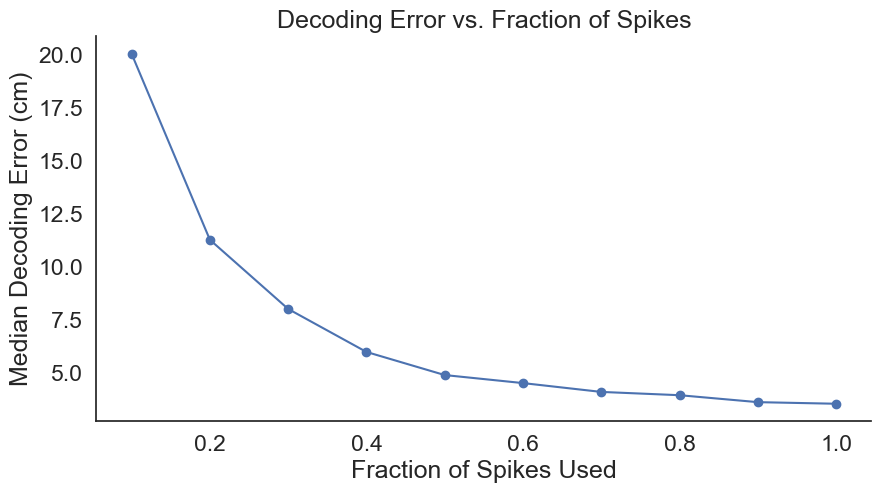

In [8]:
# Plot
plt.figure(figsize=(10, 5))
plt.plot(fractions, median_errors_A, 'o-')
plt.xlabel("Fraction of Spikes Used")
plt.ylabel("Median Decoding Error (cm)")
plt.title("Decoding Error vs. Fraction of Spikes")
plt.show()

*Comments exercise 1A*
with the fraction of spikes used on the x-axis and the median decoding error on the y-axis, it is evident that with bigger fractions the median decoding error decreases, probably because with higher fractions, more data is included, making the decoding more robust.

# Exercise 1B

In [9]:
fractions = np.linspace(0.1, 1.0, 10)  # 10% to 100%
median_errors_B = []

n_cell_list = np.arange(10, n_cells + 1, 10)  # 10, 20 to 100 cells
median_errors_B = []

for n in n_cell_list:
    # random slection
    cell_idx = np.random.choice(n_cells, n, replace=False)
    subset_spikes = [spikes[i] for i in cell_idx]
    subset_firing_rate_maps = firing_rate_maps[cell_idx, :]

    # recompute spikes_count
    spikes_count_sub = np.asarray([np.histogram(s, t)[0] for s in subset_spikes]).T

    # decode
    x_decoded_sub = np.zeros_like(true_x)
    for t_bin in tqdm(range(len(decoding_times))):
        if sum(spikes_count_sub[t_bin, :]) > 0:
            posterior = np.empty(subset_firing_rate_maps.shape[-1])
            for i in range(len(posterior)):
                posterior[i] = sum(poisson.logpmf(spikes_count_sub[t_bin, :], subset_firing_rate_maps[:, i] / fps) + pow(10, -15))
            x_decoded_sub[t_bin] = space_bins[np.argmax(posterior)]
        else:
            x_decoded_sub[t_bin] = np.nan

    # retrive meadian error
    mse = np.sqrt((true_x - x_decoded_sub)**2)
    median_errors_B.append(np.nanmedian(mse))
    print(f"Cells: {n}, Median error: {np.nanmedian(mse):.2f} cm")


100%|█████████████████████████████████████████████████████████████████████████████| 4882/4882 [00:18<00:00, 267.92it/s]


Cells: 10, Median error: 8.55 cm


100%|█████████████████████████████████████████████████████████████████████████████| 4882/4882 [00:25<00:00, 189.76it/s]


Cells: 20, Median error: 7.88 cm


100%|█████████████████████████████████████████████████████████████████████████████| 4882/4882 [00:28<00:00, 168.35it/s]


...

Cells: 80, Median error: 3.78 cm


100%|█████████████████████████████████████████████████████████████████████████████| 4882/4882 [00:43<00:00, 111.82it/s]


Cells: 90, Median error: 3.73 cm


100%|█████████████████████████████████████████████████████████████████████████████| 4882/4882 [00:42<00:00, 116.15it/s]

Cells: 100, Median error: 3.53 cm


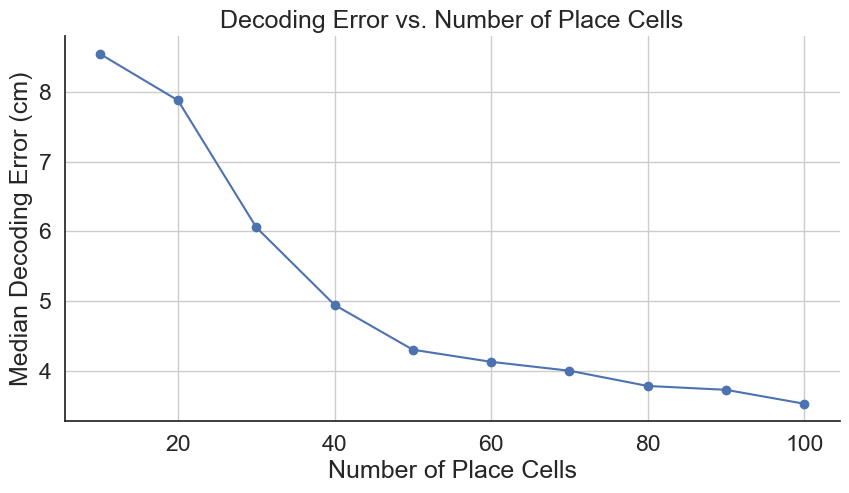

In [10]:
# Plot
plt.figure(figsize=(10, 5))
plt.plot(n_cell_list, median_errors_B, 'o-')
plt.xlabel("Number of Place Cells")
plt.ylabel("Median Decoding Error (cm)")
plt.title("Decoding Error vs. Number of Place Cells")
plt.grid(True)
plt.show()

*Comments exercise 1B* 
The median decoding error decreases with number of place cells. there is no clear asymptote visible, but the decoding error drops substantially when place cells go to 60, so 60 or more place cells would probably be optimal.

# Exercise 1C

New data generation -> noise 0.1 to 5.0 to 10

In [17]:
# --- Parameters ---
track_length = 200.0  # cm
average_firing_rate = 5  # Hz
n_cells = 100  # Number of place cells
bins = np.arange(0., track_length)  # Spatial bins

# Place field parameters
pf_centers = np.random.rand(n_cells) * track_length  # Random centers
pf_size = np.random.gamma(10, size=n_cells)  # Place field widths
pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells)  # Peak firing rates

# Generate firing rate maps
true_firing_rate_maps = np.zeros((n_cells, len(bins)))
for i in range(n_cells):
    true_firing_rate_maps[i, :] = pf_rate[i] * np.exp(-((bins - pf_centers[i])**2) / (2 * pf_size[i]**2))

# --- Generate trajectory ---
n_runs = 10
use_stops = False
av_running_speed = 10  # cm/s
fps = 10  # Frames per second

running_speed_a = np.random.chisquare(10, size=n_runs)  # Speed in direction A
running_speed_b = np.random.chisquare(10, size=n_runs)  # Speed in direction B
stopping_time_a = np.random.chisquare(15, size=n_runs)  # Stopping time at end A
stopping_time_b = np.random.chisquare(15, size=n_runs)  # Stopping time at end B

x = np.array([])
for i in range(n_runs):
    run_length_a = len(bins) * fps / running_speed_a[i]
    run1 = np.linspace(0., float(len(bins)-1), int(run_length_a))
    run_length_b = len(bins) * fps / running_speed_b[i]
    run2 = np.linspace(len(bins)-1., 0., int(run_length_b))
    x = np.concatenate((x, run1, run2))

t = np.arange(len(x)) / fps
sampling_rate = 10000.0
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
x_sampling = np.floor(np.interp(t_sampling, t, x)).astype(int)

# --- Generate spikes ---
noise_firing_rate = 10.0  # Baseline noise firing rate
spikes = []
for i in range(n_cells):
    inst_rate = true_firing_rate_maps[i, x_sampling] + noise_firing_rate
    spikes_loc = np.random.poisson(inst_rate / sampling_rate)
    sp = np.argwhere(spikes_loc)
    t_sp = t_sampling[sp]
    spikes.append(t_sp)

# --- Save data ---
file_name = 'linear_track_data3.pickle'
out_data = {
    'x': x,
    't': t,
    'spikes': spikes,
    'track_length': track_length,
    'fps': fps
}

with open(f'data/{file_name}', 'wb') as f:
    pickle.dump(out_data, f)

Data decoders

In [18]:
import ipywidgets as widgets
from ipywidgets import interact

#code: data import
data_file = 'data/linear_track_data.pickle'
with open(data_file, 'rb') as handle:
    data = pickle.load(handle)

x,t,spikes = data['x'],data['t'],data['spikes']
track_length = data['track_length']
fps = data['fps'] 
n_cells = len(spikes)

# def plot_unit(i):
   # plt.plot(t, x)
   # plt.plot(spikes[i], np.interp(spikes[i], t, x), 'r.')
    
#interact(plot_unit, i = widgets.IntSlider(min=0, max=(n_cells-1), value=0))

# we compute the poistion at which each spike was emitted
spike_positions = [np.interp(s, t, x) for s in spikes]
space_bins = np.arange(0., track_length, 5.) # binning in bins of 5 cms

# we compute histograms for each cell
spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
spikes_hist = np.asarray(spikes_hist)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
occupancy = np.histogram(x, space_bins)[0] /  fps

firing_rate_maps = spikes_hist / occupancy 

spikes_count= [np.histogram(s,t)[0] for s in spikes]
spikes_count = np.asarray(spikes_count).T # we transpose the matrix to have the more familiar (samples x features) shape

# code decoding
from scipy.stats import poisson

true_x = x[:-1] # get rid of last timepoint to have same length as binned spikes
decoding_times = t[:-1]

x_decoded = np.zeros_like(true_x)

for t_bin in tqdm(range(len(decoding_times))):
    if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
        posterior = np.empty(firing_rate_maps.shape[-1])

        for i in range(len(posterior)):
            # Note that we work with log so that we can sum probabilities
            # instead of multiplying them 
            #posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
            posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15))


        x_decoded[t_bin] = space_bins[np.argmax(posterior)]
    else:
        x_decoded[t_bin] = np.nan 

mse = np.sqrt((true_x-x_decoded)**2)
print(f'Median error: {np.nanmedian(mse)} cm')

100%|█████████████████████████████████████████████████████████████████████████████| 4882/4882 [00:23<00:00, 207.72it/s]

Median error: 3.526315789473699 cm


In [19]:
import ipywidgets as widgets
from ipywidgets import interact

#code: data import
data_file = 'data/linear_track_data2.pickle'
with open(data_file, 'rb') as handle:
    data = pickle.load(handle)

x,t,spikes = data['x'],data['t'],data['spikes']
track_length = data['track_length']
fps = data['fps'] 
n_cells = len(spikes)

# def plot_unit(i):
   # plt.plot(t, x)
   # plt.plot(spikes[i], np.interp(spikes[i], t, x), 'r.')
    
#interact(plot_unit, i = widgets.IntSlider(min=0, max=(n_cells-1), value=0))

# we compute the poistion at which each spike was emitted
spike_positions = [np.interp(s, t, x) for s in spikes]
space_bins = np.arange(0., track_length, 5.) # binning in bins of 5 cms

# we compute histograms for each cell
spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
spikes_hist = np.asarray(spikes_hist)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
occupancy = np.histogram(x, space_bins)[0] /  fps

firing_rate_maps = spikes_hist / occupancy 

spikes_count= [np.histogram(s,t)[0] for s in spikes]
spikes_count = np.asarray(spikes_count).T # we transpose the matrix to have the more familiar (samples x features) shape

# code decoding
from scipy.stats import poisson

true_x = x[:-1] # get rid of last timepoint to have same length as binned spikes
decoding_times = t[:-1]

x_decoded = np.zeros_like(true_x)

for t_bin in tqdm(range(len(decoding_times))):
    if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
        posterior = np.empty(firing_rate_maps.shape[-1])

        for i in range(len(posterior)):
            # Note that we work with log so that we can sum probabilities
            # instead of multiplying them 
            #posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
            posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15))


        x_decoded[t_bin] = space_bins[np.argmax(posterior)]
    else:
        x_decoded[t_bin] = np.nan 

mse = np.sqrt((true_x-x_decoded)**2)
print(f'Median error: {np.nanmedian(mse)} cm')

100%|█████████████████████████████████████████████████████████████████████████████| 5284/5284 [00:24<00:00, 217.39it/s]

Median error: 8.6930360488288 cm


In [20]:
import ipywidgets as widgets
from ipywidgets import interact

#code: data import
data_file = 'data/linear_track_data3.pickle'
with open(data_file, 'rb') as handle:
    data = pickle.load(handle)

x,t,spikes = data['x'],data['t'],data['spikes']
track_length = data['track_length']
fps = data['fps'] 
n_cells = len(spikes)

# def plot_unit(i):
   # plt.plot(t, x)
   # plt.plot(spikes[i], np.interp(spikes[i], t, x), 'r.')
    
#interact(plot_unit, i = widgets.IntSlider(min=0, max=(n_cells-1), value=0))

# we compute the poistion at which each spike was emitted
spike_positions = [np.interp(s, t, x) for s in spikes]
space_bins = np.arange(0., track_length, 5.) # binning in bins of 5 cms

# we compute histograms for each cell
spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
spikes_hist = np.asarray(spikes_hist)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
occupancy = np.histogram(x, space_bins)[0] /  fps

firing_rate_maps = spikes_hist / occupancy 

spikes_count= [np.histogram(s,t)[0] for s in spikes]
spikes_count = np.asarray(spikes_count).T # we transpose the matrix to have the more familiar (samples x features) shape

# code decoding
from scipy.stats import poisson

true_x = x[:-1] # get rid of last timepoint to have same length as binned spikes
decoding_times = t[:-1]

x_decoded = np.zeros_like(true_x)

for t_bin in tqdm(range(len(decoding_times))):
    if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
        posterior = np.empty(firing_rate_maps.shape[-1])

        for i in range(len(posterior)):
            # Note that we work with log so that we can sum probabilities
            # instead of multiplying them 
            #posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
            posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15))


        x_decoded[t_bin] = space_bins[np.argmax(posterior)]
    else:
        x_decoded[t_bin] = np.nan 

mse = np.sqrt((true_x-x_decoded)**2)
print(f'Median error: {np.nanmedian(mse)} cm')

100%|█████████████████████████████████████████████████████████████████████████████| 5306/5306 [00:22<00:00, 231.49it/s]


Median error: 9.900290375184134 cm


* Comments exercise 1C*
i have generated new data with a noise value of 5 and 10. The low noise value resulted  in a median error of 3.53 cm, whereas the high noise values resulted in a higher median error values of 8.69 and 9.9. So the higher noise firing rate value, the higher the randomness in spikes, the higher the error in the decoder.